In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

import seaborn as sns
from helper_functions_robustness import *

## Pre-process the robustness

In [10]:
# setup attributes
sim_mode = 'p90'
num_sol_dict = {'base': 46, 'IU': 628}
yticks_max = {'avg': [0.0, 0.5, 1.0], 'p90': [0.0, 0.45, 0.90]}
sim_mode_colors = {'base': '#6B8F71', 'IU': '#F2B880'}
utilities = ['Watertown', 'Dryville', 'Fallsland']
util_abbrevs = ['W', 'D', 'F']
obj_names = ['REL', 'RF', 'INPC', 'PFC', 'WCC']
objs_allutils = [obj_name + f'_{util_abbrev}' for util_abbrev in util_abbrevs for obj_name in obj_names]
objs_regional = [obj_name + '_R' for obj_name in obj_names]

high_coop_base_solutions = [[29]]  
high_coop_IU_solutions = [[552], [260]]   # 363 (PR) and 552 (SP)

In [4]:
'''
# calculate robustness for all IU solutions
directory_IU = f'output_sim_{sim_mode}_refset_IU_reeval_v2'
robustness_allsols_IU = np.zeros((num_sol_dict['IU'], len(utilities)+1), dtype=float)

for sol_num in range(num_sol_dict['IU']):
    filename = f'combined_objs_sol{sol_num}.csv'
    robustness_allsols_IU[sol_num, :] = calc_robustness(directory_IU, filename, obj_names, objs_allutils, [0.98, 0.1, 0.1])

# convert to dataframe
robustness_df_IU = pd.DataFrame(robustness_allsols_IU, columns=utilities + ['Regional'])

# save the robustness dataframes to csv
robustness_df_IU.to_csv(f'robustness_sim_{sim_mode}_refset_IU_v2.csv', index=False)

# calculate robustness for all base solutions
directory_base = f'output_sim_{sim_mode}_refset_base_reeval_v2'
robustness_allsols_base = np.zeros((num_sol_dict['base'], len(utilities)+1), dtype=float)

for sol_num in range(num_sol_dict['base']):
    filename = f'combined_objs_sol{sol_num}.csv'
    robustness_allsols_base[sol_num, :] = calc_robustness(directory_base, filename, obj_names, objs_allutils, [0.98, 0.1, 0.1])

# convert to dataframe
robustness_df_base = pd.DataFrame(robustness_allsols_base, columns=utilities + ['Regional'])
# save the robustness dataframes to csv
robustness_df_base.to_csv(f'robustness_sim_{sim_mode}_refset_base_v2.csv', index=False)
'''

"\n# calculate robustness for all IU solutions\ndirectory_IU = f'output_sim_{sim_mode}_refset_IU_reeval_v2'\nrobustness_allsols_IU = np.zeros((num_sol_dict['IU'], len(utilities)+1), dtype=float)\n\nfor sol_num in range(num_sol_dict['IU']):\n    filename = f'combined_objs_sol{sol_num}.csv'\n    robustness_allsols_IU[sol_num, :] = calc_robustness(directory_IU, filename, obj_names, objs_allutils, [0.98, 0.1, 0.1])\n\n# convert to dataframe\nrobustness_df_IU = pd.DataFrame(robustness_allsols_IU, columns=utilities + ['Regional'])\n\n# save the robustness dataframes to csv\nrobustness_df_IU.to_csv(f'robustness_sim_{sim_mode}_refset_IU_v2.csv', index=False)\n\n# calculate robustness for all base solutions\ndirectory_base = f'output_sim_{sim_mode}_refset_base_reeval_v2'\nrobustness_allsols_base = np.zeros((num_sol_dict['base'], len(utilities)+1), dtype=float)\n\nfor sol_num in range(num_sol_dict['base']):\n    filename = f'combined_objs_sol{sol_num}.csv'\n    robustness_allsols_base[sol_num, :

In [11]:
# read in the robustness dataframes from csv
robustness_df_IU = pd.read_csv(f'robustness_sim_{sim_mode}_refset_IU.csv')
robustness_df_base = pd.read_csv(f'robustness_sim_{sim_mode}_refset_base.csv')

sols_to_highlight = {"baseline": high_coop_base_solutions[0],
                     "IU social planner": high_coop_IU_solutions[0],
                     "IU power index": high_coop_IU_solutions[1]}


In [6]:
# maintain only IU solutions that have higher regional robustness than their counterparts in the base set
robustness_df_IU_higherthanbase = robustness_df_IU[robustness_df_IU['Regional'] > robustness_df_base['Regional'].median()]
robustness_df_IU_idx = robustness_df_IU_higherthanbase.index.tolist()

#save the indices of the high-cooperation solutions that have higher regional robustness than the base set
#np.savetxt(f"high_robustness_sols.csv", robustness_df_IU_higherthanbase.index, fmt='%d')

In [12]:
color_dict_coop = {'other': "#E6E6E6", 'base': "#39563D",
                        'IU power index': "#F1AF35", 'IU social planner': "#B66D0D"}
robustness_df_base_cat = robustness_df_base.copy()
robustness_df_IU_cat = robustness_df_IU.copy()
robustness_df_base_cat['Category'] = 'other'
robustness_df_IU_cat['Category'] = 'other'

robustness_df_base_cat['Category'] = ['base' if i in high_coop_base_solutions[0] else 'other' for i in robustness_df_base_cat.index]
robustness_df_IU_cat['Category'] = ['IU social planner' if i in high_coop_IU_solutions[0] else 'IU power index' if i in high_coop_IU_solutions[1] else 'other' for i in robustness_df_IU_cat.index]

robustness_IU_highcoop = pd.DataFrame(robustness_df_IU_cat.iloc[[high_coop_IU_solutions[0][0], high_coop_IU_solutions[1][0]]])
robustness_base_highcoop = pd.DataFrame(robustness_df_base_cat.iloc[[high_coop_base_solutions[0][0]]])

robustness_IU_cat = pd.concat([robustness_df_IU_cat, robustness_df_IU_cat.iloc[high_coop_IU_solutions[0]], robustness_df_IU_cat.iloc[high_coop_IU_solutions[1]]], axis=0, ignore_index=True)
robustness_base_cat = pd.concat([robustness_df_base_cat, robustness_df_base_cat.iloc[high_coop_base_solutions[0]]], axis=0, ignore_index=True)

# drop the regional column for plotting
robustness_df_base_cat_noReg = robustness_df_base_cat.drop(columns=['Regional'])
robustness_df_IU_cat_noReg = robustness_df_IU_cat.drop(columns=['Regional'])
robustness_base_cat_noReg = robustness_base_cat.drop(columns=['Regional'])
robustness_IU_cat_noReg = robustness_IU_cat.drop(columns=['Regional'])
robustness_IU_highcoop_noReg = robustness_IU_highcoop.drop(columns=['Regional'])
robustness_base_highcoop_noReg = robustness_base_highcoop.drop(columns=['Regional'])


## Plot the robustness tradeoffs

In [13]:
from matplotlib import colormaps, cm
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from pandas.plotting import parallel_coordinates
from parallel_plot_functions import *

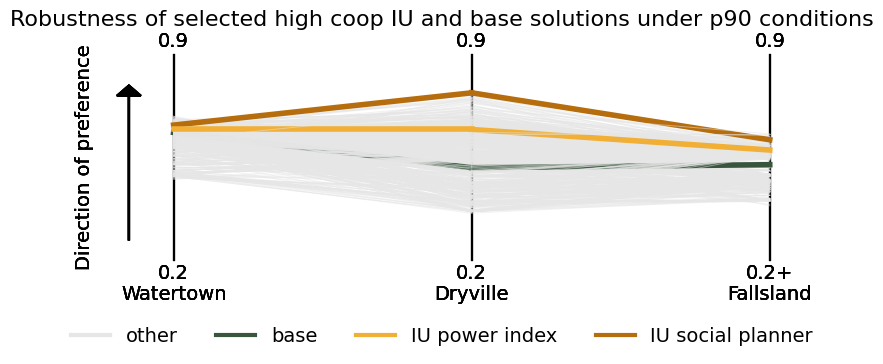

In [15]:
fig, ax = plt.subplots(1,1,figsize=(10,4), gridspec_kw={'hspace':0.1, 'wspace':0.1})
axis_labels = utilities
figname_IU = f'robustness_parallel_base_IU_{sim_mode}'
#axis_mins = robustness_IU_cat_noReg.min().values[:-1] - 0.1
#axis_maxs = robustness_IU_cat_noReg.max().values[:-1] + 0.1
axis_mins = [0.2, 0.2, 0.2]
axis_maxs = [0.9, 0.9, 0.9]
# set axis_maxs to 1.0 if greater than 1.0
#axis_maxs = np.where(axis_maxs > 1.0, 1.0, axis_maxs)
custom_parallel_coordinates(fig, ax, robustness_IU_cat_noReg, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='top', zorder_by=2,
                                alpha_base=0.5, lw_base=0.75, fontsize=14,
                                minmaxs=['max', 'max', 'max'],
                                color_by_categorical='Category',
                                color_dict_categorical=color_dict_coop,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 
                                
custom_parallel_coordinates(fig, ax, robustness_base_cat_noReg, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='top', 
                                alpha_base=0.5, lw_base=0.75, fontsize=14,
                                minmaxs=['max', 'max', 'max'],
                                color_by_categorical='Category',
                                color_dict_categorical=color_dict_coop,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 

custom_parallel_coordinates(fig, ax, robustness_IU_highcoop_noReg, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='top', zorder_by=2,
                                alpha_base=1.0, lw_base=4, fontsize=14,
                                minmaxs=['max', 'max', 'max'],
                                color_by_categorical='Category',
                                color_dict_categorical=color_dict_coop,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 

custom_parallel_coordinates(fig, ax, robustness_base_highcoop_noReg, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='top', zorder_by=2,
                                alpha_base=1.0, lw_base=4, fontsize=14,
                                minmaxs=['max', 'max', 'max'],
                                color_by_categorical='Category',
                                color_dict_categorical=color_dict_coop,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 

# add legend for high/low cooperation
'''
legend_elements = [Line2D([0], [0], color=color_dict_coop['base_high_coop'], lw=4, label='High cooperation'),
                   Line2D([0], [0], color=color_dict_coop['base_low_coop'], lw=4, label='Low cooperation'),
                   Line2D([0], [0], color='lightgrey', lw=4, label='Other solutions')]
ax.legend(handles=legend_elements, fontsize=10, bbox_to_anchor=(0.5, 0.005), 
          loc='lower center', frameon=False, ncol=3)
'''
plt.title(f'Robustness of selected high coop IU and base solutions under {sim_mode} conditions', fontsize=16)
plt.savefig(f'figures/{figname_IU}_original_newver.pdf', bbox_inches='tight', dpi=300)

plt.show()

### Plot robustness scatterplot

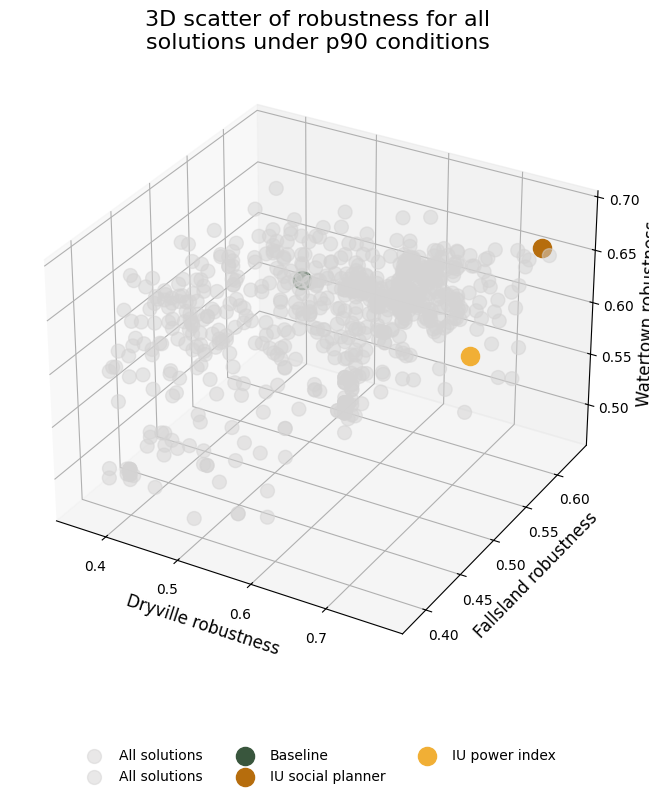

In [8]:
# plot 3D scatter highlighting the three highlighted solutions
fig, ax3d = plt.subplots(1,1,figsize=(8,8), subplot_kw={'projection': '3d'})
figname_3d = f'robustness_3Dscatter_base_IU_{sim_mode}'
ax3d.scatter(robustness_df_base['Dryville'], robustness_df_base['Fallsland'], robustness_df_base['Watertown'], 
             color="#D4D3D3", s=100, alpha=0.5, label='All solutions')
ax3d.scatter(robustness_df_IU['Dryville'], robustness_df_IU['Fallsland'], robustness_df_IU['Watertown'], 
             color="#D4D3D3", s=100, alpha=0.5, label='All solutions')
ax3d.scatter(robustness_df_base.loc[29, 'Dryville'], robustness_df_base.loc[29, 'Fallsland'], robustness_df_base.loc[29, 'Watertown'],
             color=color_dict_coop['base'], s=170, label='Baseline')
ax3d.scatter(robustness_df_IU.loc[401, 'Dryville'], robustness_df_IU.loc[552, 'Fallsland'], robustness_df_IU.loc[401, 'Watertown'],
             color=color_dict_coop['IU social planner'], s=170, label='IU social planner')
ax3d.scatter(robustness_df_IU.loc[363, 'Dryville'], robustness_df_IU.loc[154, 'Fallsland'], robustness_df_IU.loc[61, 'Watertown'],
             color=color_dict_coop['IU power index'], s=170, label='IU power index')
ax3d.set_xlabel('Dryville robustness', fontsize=12)
ax3d.set_ylabel('Fallsland robustness', fontsize=12)
ax3d.set_zlabel('Watertown robustness', fontsize=12)

ax3d.set_title(f'3D scatter of robustness for all\nsolutions under {sim_mode} conditions', fontsize=16)
ax3d.legend(fontsize=10, loc='lower center', bbox_to_anchor=(0.5, -0.20), ncol=3, frameon=False)
#plt.savefig(f'figures/{figname_3d}_original.pdf', bbox_inches='tight', dpi=300)
plt.show()

### Plot the bar plots

Text(0.5, 0.95, 'Robustness under p90 conditions')

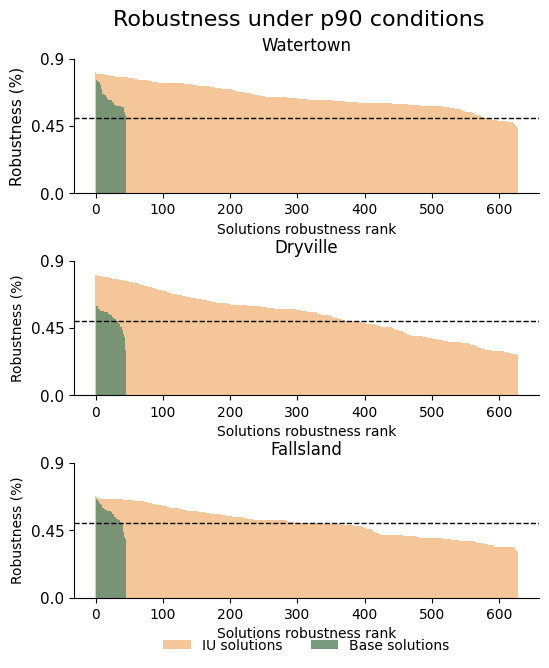

In [21]:
#robustness_df_IU_filtered = robustness_df_IU.loc[solutions_IU_morerobust]
fig, axs = plt.subplots(3, 1, figsize=(6,7), sharey=True, gridspec_kw={'wspace':0.2, 'hspace':0.5})
utilities = ['Watertown', 'Dryville', 'Fallsland', 'Regional']
plot_robustness_bar(robustness_df_base, robustness_df_IU, 'Watertown', axs[0], sim_mode_colors)
plot_robustness_bar(robustness_df_base, robustness_df_IU, 'Dryville', axs[1], sim_mode_colors)
plot_robustness_bar(robustness_df_base, robustness_df_IU, 'Fallsland', axs[2], sim_mode_colors)

# for each axis, set the y-limit between 0 and 1
for i, ax in enumerate(axs):
    ax.set_yticks(yticks_max[sim_mode])
    ax.set_yticklabels(yticks_max[sim_mode], fontsize=11)
    # draw a horizontal grid line at y=0.5
    ax.axhline(y=0.5, color='k', linestyle='--', linewidth=1.0)
    ax.set_title(f'{utilities[i]}', fontsize=12)
    ax.set_xlabel('Solutions robustness rank', fontsize=10)
    # plot horizontal gridlines
axs[0].set_ylabel('Robustness (%)', fontsize=11)

# set legend at the bottom of the figure without a box
handles, labels = axs[0].get_legend_handles_labels()
labels[0] = 'IU solutions'
labels[1] = 'Base solutions'
plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2, frameon=False, fontsize=10)

plt.suptitle(f'Robustness under {sim_mode} conditions', fontsize=16, y=0.95)
#plt.tight_layout()
#plt.savefig(f'figures/robustness_{sim_mode}_conditions_noREG.pdf', bbox_inches='tight')


In [ ]:
def plot_robustness_bar_selected(robustness_base, robustness_IU, utility, ax, 
                             color_dict, sols_to_highlight=None):
    sim_mode_colors = {'base': '#39563D', 'IU': '#F2B880'}

    robustness_base_u = robustness_base[utility].values
    robustness_IU_u = robustness_IU[utility].values
    # arrange the data in descending order of robustness
    robustness_base_sorted = np.sort(robustness_base_u)[::-1]
    robustness_IU_sorted = np.sort(robustness_IU_u)[::-1]

    width = 3.0 # the width of the bars
    # create a bar plot of robustness values where height is robustness
    ax.bar(np.arange(len(robustness_IU_sorted)), robustness_IU_sorted, width=width, 
           color=sim_mode_colors['IU'], alpha=0.15)
    ax.bar(np.arange(len(robustness_base_sorted))+0.5, robustness_base_sorted, width=width, 
           color=sim_mode_colors['base'], alpha=0.15)
    
    # iterate through the keys and values of sols_to_highlight dict
    for sol_key in sols_to_highlight.keys():
        sol = sols_to_highlight[sol_key]
        sol_color = color_dict[sol_key]
        robustness_value = 0.0
        robustness_idx = 0
        # if the sol_key contains 'base', get robustness from base dataframe, else from IU dataframe
        if 'IU' in sol_key:
            robustness_value = robustness_IU_u[sol]
            robustness_idx = np.where(robustness_IU_sorted == robustness_value)[0][0]
        else:
            robustness_value = robustness_base_u[sol]
            robustness_idx = np.where(robustness_base_sorted == robustness_value)[0][0]
        #robustness_value = robustness_IU_u[sol]
        #robustness_idx = np.where(robustness_IU_sorted == robustness_value)[0][0]
        ax.bar(robustness_idx, robustness_value, width=width*4, color=sol_color, alpha=1.0,
               label=f'{sol_key}')
    # turn the right and top axes invisible 
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.set_title(f'{utility}', fontsize=12)


In [ ]:
'''
color_map = {
    'Baseline': sim_mode_colors_base.get('low-coop', '#3E8D8F'),
    'High-coop-407': sim_mode_colors_IU.get('high-coop-407', '#pwB13C'),
    'High-coop-129': sim_mode_colors_IU.get('high-coop-129', '#B66D0D'),
    'High-coop-579': sim_mode_colors_IU.get('high-coop-579', "#FF8847"),
}

sim_mode_colors_coop = {'base_36': "#3E8D8F", 
                        'IU_407': "#pwB13C", 'IU_129': "#B66D0D", 'IU_7': "#F5925D"}

sols_to_highlight = {"base_36": [36],
                     "IU_407": [407],
                     "IU_129": [129],
                     "IU_7": [7],}

sim_mode_colors_IU = {'others': 'gainsboro','iu-pw': "#pwB13C", 'iu-sp': "#B66D0D"}
sim_mode_colors_base = {'others': 'gainsboro', 'base-pw': "#6B8F71", 'base-sp': "#39563D"}
'''

sim_mode_colors_coop = {'baseline': "#39563D",
                        'IU power index': "#F1AF35", 'IU social planner': "#B66D0D"}

fig, axs = plt.subplots(1, 3, figsize=(14, 2), sharey=True, gridspec_kw={'wspace':0.1})
plot_robustness_bar_selected(robustness_df_base, robustness_df_IU, 'Watertown', axs[0], sim_mode_colors_coop, sols_to_highlight=sols_to_highlight)
plot_robustness_bar_selected(robustness_df_base, robustness_df_IU, 'Dryville', axs[1], sim_mode_colors_coop, sols_to_highlight=sols_to_highlight)
plot_robustness_bar_selected(robustness_df_base, robustness_df_IU, 'Fallsland', axs[2], sim_mode_colors_coop, sols_to_highlight=sols_to_highlight)

# draw a horizontal line at y=0.8 in each subplot
for ax in axs:
    ax.set_ylim(0.0, 1)
    ax.set_yticks(yticks_max[sim_mode])
    ax.set_yticklabels(yticks_max[sim_mode], fontsize=11)
    ax.axhline(y=0.4, color='gray', linestyle='--', linewidth=0.95)
    ax.set_xlabel('Solutions', fontsize=10)

# set legend at the bottom of the figure without a box
handles, labels = axs[0].get_legend_handles_labels()
labels[0] = 'Baseline'
labels[1] = 'IU Idealist'
labels[2] = 'IU Pragmatist'

axs[0].set_ylabel(f'Robustness (%)', fontsize=10)
axs[1].legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=3, frameon=False, fontsize=10)

#plt.suptitle(f'Robustness under {sim_mode} conditions', fontsize=12)
#plt.tight_layout()
plt.savefig(f'figures/robustness_{sim_mode}_selectedsols_newver.pdf')
plt.show()

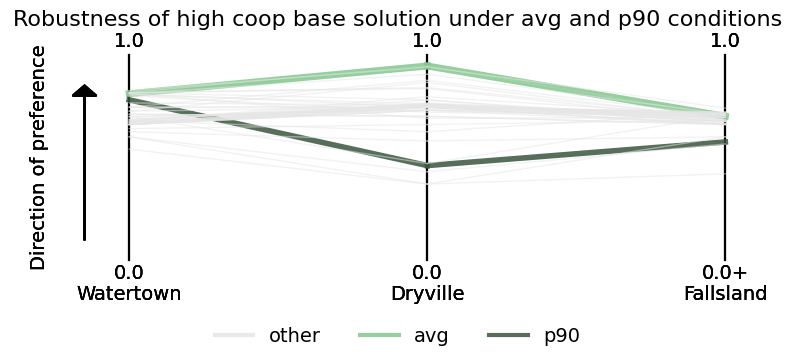

In [8]:
# read in the robustness dataframes from csv
robustness_df_avg = pd.read_csv(f'robustness_sim_avg_refset_base.csv')
robustness_df_p90 = pd.read_csv(f'robustness_sim_p90_refset_base_v2.csv')

robustness_df_avg['Category'] = 'other'
robustness_df_p90['Category'] = 'other'

robustness_df_avg['Category'] = ['avg' if i in high_coop_base_solutions[0] else 'other' for i in robustness_df_avg.index]
robustness_df_p90['Category'] = ['p90' if i in high_coop_base_solutions[0] else 'other' for i in robustness_df_p90.index]
robustness_43_avg = pd.DataFrame(robustness_df_avg.iloc[high_coop_base_solutions[0]])
robustness_43_p90 = pd.DataFrame(robustness_df_p90.iloc[high_coop_base_solutions[0]])
# drop the regional column for plotting
robustness_df_avg_noReg = robustness_df_avg.drop(columns=['Regional'])
robustness_df_p90_noReg = robustness_df_p90.drop(columns=['Regional'])
color_dict_coop_bavg = {'other': "#E6E6E6", 'avg': "#83C78D", 'p90': "#39563D"}
fig, ax = plt.subplots(1,1,figsize=(10,4), gridspec_kw={'hspace':0.1, 'wspace':0.1})
axis_labels = ['Watertown', 'Dryville', 'Fallsland'] 
figname_base = f'robustness_parallel_base_avg_p90'
axis_mins = [0.0, 0.0, 0.0]
axis_maxs = [1.0, 1.0, 1.0]

custom_parallel_coordinates(fig, ax, robustness_df_avg_noReg, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='top', zorder_by=2,
                                alpha_base=0.5, lw_base=1.0, fontsize=14,
                                minmaxs=['max', 'max', 'max'],
                                color_by_categorical='Category',
                                color_dict_categorical=color_dict_coop_bavg,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 
                                
custom_parallel_coordinates(fig, ax, robustness_43_avg, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='top', 
                                alpha_base=0.85, lw_base=5, fontsize=14,
                                minmaxs=['max', 'max', 'max'],
                                color_by_categorical='Category',
                                color_dict_categorical=color_dict_coop_bavg,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 

custom_parallel_coordinates(fig, ax, robustness_43_p90, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='top', 
                                alpha_base=0.85, lw_base=4, fontsize=14,
                                minmaxs=['max', 'max', 'max'],
                                color_by_categorical='Category',
                                color_dict_categorical=color_dict_coop_bavg,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 

plt.title(f'Robustness of high coop base solution under avg and p90 conditions', fontsize=16)
#plt.savefig(f'figures/robustness_parallel_base_avg_p90.pdf', bbox_inches='tight', dpi=300)
plt.show()